# Do open concepts spread across more fields? — RQ2-D1 screen test (demo)

This notebook demonstrates the **modelling stage** of the RQ2-D1 experiment: *does the openness of a new scientific
concept's co-word neighbourhood at year t predict how far the concept spreads across disciplines in the next five years
(W2 = [t+1, t+5])?*

**The full pipeline** (`method.py`) orchestrates 12 stages. The first eight rebuild everything from a 462,812-work corpus:
`vendor` (unit tests), `population` (frozen MAIN / STRICT / SENSITIVITY concept populations, sealed held-out ids),
`prep`, `attach` (25 prebuilt co-word snapshots), `indicators`, `openness`, `features` and `outcomes`. The result is
**one row per (concept, analysis year t)**, `results/d1/panel_ct.parquet`, which holds:

* **openness at t**, measured three ways: `closure_res` (top-20 Chung-Lu closure, residualised on new-relation rate, novelty,
  beta_sim, log vol3, age and H_W1; the R1a model), Burt `constraint` / effective size, and excess cross-community pairs
  `xcomm_exc`. `*_z` columns are z-scores. `closure_res_imp` is the imputed co-primary measure.
* **BASE covariates** from W1: entropy `H_W1`, active subfields, log volume, momentum, growing-edge breadth `GEB`, Kleinberg burst,
  Rafols coherence, `P_rar`, plus origin, F-band, route and year dummies.
* **Outcomes** on W2: rarefied Shannon change `Y1r`, Rao-Stirling change `Y2`, and new subfields reached by author-disjoint
  newcomers `Y3` (modelled as `log1p_Y3`).

This demo starts from a **100-row subset of that panel** (26 whole concepts, 22 of them in MAIN). It runs the original
`models` stage code (`src/models.py` + `src/stats_core.py`) almost unchanged:

1. OLS `Y ~ BASE + openness_z` with a concept-cluster bootstrap and CR1 SEs, Holm-adjusted over the 3 outcomes.
2. Grouped-by-concept 5-fold CV ΔR² (FULL − BASE) with a concept-bootstrap CI.
3. The pre-declared decision rule, which yields `D1_SUPPORTED_SCREEN` or `D1_NOT_SUPPORTED_SCREEN`.
4. Secondary analyses: the within-E_up subset, a robustness grid, descriptive mediation, partial dependence, a VIF check and sanity checks.

The full run (659 rows, 168 concepts, B = 2000) reported **D1_NOT_SUPPORTED_SCREEN**: on this data, openness does not
predict *where* concepts travel beyond growth and level baselines. On 100 rows the estimates are much noisier. The last
cell compares them with the full-run reference.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, statsmodels, matplotlib, pyarrow — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0', 'pyarrow==18.1.0')

In [2]:
# --- original imports of src/models.py and src/stats_core.py ---
from __future__ import annotations

import json
import math

import numpy as np
import pandas as pd
import statsmodels.api as sm
from loguru import logger
from scipy import stats

# `import common as K`, `import lib_metrics as lm`, `import stats_core as S` and `from openness import R1A` are
# replaced below by the inlined definitions (the repo modules have import-time side effects tied to the run tree).

# --- additional imports for the notebook ---
import sys
import time
import types
from pathlib import Path
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_F1tk5OGtH84L/round-3/experiment-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(json.dumps(data["metadata"], indent=1))
print("panel rows:", len(data["panel"]), "| R1a fit rows:", len(data["r1a_fitrows"]))

{
 "description": "RQ2-D1 screen panel subset: one row per (concept, analysis year t) with W1 baselines, openness at t (closure_res etc., z-scored on the full panel) and W2=[t+1,t+5] breadth outcomes (Y1r, Y2, Y3).",
 "source": "results/d1/panel_ct.parquet (+ work/indicators_open.parquet for the R1a fit rows) of the RQ2-D1 experiment",
 "n_rows": 100,
 "n_concepts": 26,
 "n_rows_MAIN": 85,
 "n_concepts_MAIN": 22,
 "full_panel_rows": 659,
 "full_panel_concepts": 168,
 "selection": "whole concepts, stratified by population (MAIN vs SENSITIVITY-only) and origin group; seed 7"
}
panel rows: 100 | R1a fit rows: 100


## Configuration

These are all the tunable parameters of the `models` stage. The original values are noted in the comments: the
`--boot 2000` CLI default, `Bg = 1000` for the robustness grid, 20 CV repeats, 200 placebo permutations, 10 label
shuffles, and 5 CV repeats inside the sanity checks. The demo panel has only 100 rows, so the original values fit well
inside the runtime budget.

In [5]:
BOOT = 2000             # B: cluster-bootstrap draws for OLS / CV / mediation (original: 2000; --mini: 200)
BOOT_GRID = 1000        # Bg: bootstrap draws per robustness-grid spec (original: 1000; --mini: 200)
CV_REPS = 20            # repeats of grouped 5-fold CV (original: 20)
N_PLACEBO = 200         # sanity: within-year permutations of closure_res (original: 200)
N_SHUFFLE = 10          # sanity: label-shuffle CV runs (original: 10)
SANITY_CV_REPS = 5      # sanity: CV repeats inside placebo / leaky checks (original: 5)
BOOT_STAB = (1000, 2000)  # sanity: bootstrap-stability comparison B1 vs B2 (original: (1000, 2000))

## Statistical core (`src/stats_core.py`, verbatim)

These are numpy-only, deterministic helpers:

* `design`: builds the design matrix `[const, lead…, BASE numerics…, drop-first dummies]`. The openness measure always sits
  at column 1.
* `cr1`: OLS with CR1 cluster-robust SEs, clustered by concept.
* `cluster_boot` / `boot_summary`: concept-cluster bootstrap of the openness coefficient, giving a percentile CI and a two-sided bootstrap p.
* `grouped_cv` / `delta_r2_boot`: out-of-fold predictions for BASE and FULL, averaged over repeated grouped K-fold splits,
  and a concept-bootstrap CI on ΔR².

In [6]:
NUM_BASE = ["H_W1", "n_active_W1", "log_vol_W1", "momentum", "GEB", "burst_state", "rafols_coh_f", "coh_missing",
            "P_rar_f", "P_rar_missing"]
CATS = ["origin_group", "F_band", "route", "t"]
TURNOVER = ["new_relation_rate", "novelty", "beta_sim_rar_f", "beta_sim_missing"]


def design(d: pd.DataFrame, lead: list[str], num: list[str] = NUM_BASE, cats: list[str] = CATS,
           levels: dict | None = None) -> tuple[np.ndarray, list[str], dict]:
    '''[const, lead..., num..., drop-first dummies]; lead columns sit at positions 1..len(lead).

    `levels` (from a previous call) freezes dummy coding, e.g. for held-out rows.
    '''
    cols = [np.ones(len(d))]
    names = ["const"]
    for c in lead + num:
        cols.append(d[c].astype(float).values)
        names.append(c)
    lv_out = {}
    for c in cats:
        vals = d[c].astype(str).values
        lv = levels[c] if levels is not None else sorted(set(vals))
        lv_out[c] = lv
        for v in lv[1:]:
            cols.append((vals == v).astype(float))
            names.append(f"{c}={v}")
    X = np.column_stack(cols)
    if levels is None:  # drop constant dummy / numeric columns (never const or lead)
        keep = [i for i in range(X.shape[1]) if i <= len(lead) or np.ptp(X[:, i]) > 0]
        X = X[:, keep]
        names = [names[i] for i in keep]
    return X, names, lv_out


def ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.linalg.lstsq(X, y, rcond=None)[0]


def cr1(X: np.ndarray, y: np.ndarray, g: np.ndarray, beta: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray]:
    '''Coefficients and CR1 cluster-robust SEs (Stata small-sample factor).'''
    beta = ols(X, y) if beta is None else beta
    u = y - X @ beta
    n, k = X.shape
    XtXi = np.linalg.pinv(X.T @ X)
    uniq, inv = np.unique(g, return_inverse=True)
    G = len(uniq)
    S = np.zeros((G, k))
    np.add.at(S, inv, X * u[:, None])
    meat = S.T @ S
    V = XtXi @ meat @ XtXi * (G / (G - 1)) * ((n - 1) / max(n - k, 1))
    return beta, np.sqrt(np.clip(np.diag(V), 0, None))


def blocks_of(g: np.ndarray) -> list[np.ndarray]:
    uniq, inv = np.unique(g, return_inverse=True)
    order = np.argsort(inv, kind="stable")
    cuts = np.cumsum(np.bincount(inv))[:-1]
    return np.split(order, cuts)


def cluster_boot(X: np.ndarray, y: np.ndarray, g: np.ndarray, B: int, seed: int, j: int | list = 1) -> np.ndarray:
    blocks = blocks_of(g)
    G = len(blocks)
    rng = np.random.default_rng(seed)
    jj = np.atleast_1d(j)
    out = np.empty((B, len(jj)))
    for b in range(B):
        idx = np.concatenate([blocks[k] for k in rng.integers(0, G, G)])
        out[b] = ols(X[idx], y[idx])[jj]
    return out[:, 0] if np.ndim(j) == 0 else out


def boot_summary(est: float, draws: np.ndarray) -> dict:
    B = len(draws)
    lo, hi = np.percentile(draws, [2.5, 97.5])
    n_le, n_ge = int(np.sum(draws <= 0)), int(np.sum(draws >= 0))
    p = min(1.0, 2 * min((n_le + 1) / (B + 1), (n_ge + 1) / (B + 1)))
    return dict(coef=float(est), ci_lo=float(lo), ci_hi=float(hi), p_boot=float(p), boot_sd=float(np.std(draws, ddof=1)))


def r2(y: np.ndarray, p: np.ndarray) -> float:
    sst = float(np.sum((y - y.mean()) ** 2))
    return float(1 - np.sum((y - p) ** 2) / sst) if sst > 0 else math.nan


def fold_assign(g: np.ndarray, k: int, seed: int) -> np.ndarray:
    '''Concepts shuffled (seeded) then dealt round-robin into k folds (grouped K-fold with shuffled group order).'''
    uniq = np.unique(g)
    perm = np.random.default_rng(seed).permutation(uniq)
    f_of = {c: i % k for i, c in enumerate(perm)}
    return np.array([f_of[c] for c in g])


def grouped_cv(Xb: np.ndarray, Xf: np.ndarray | None, y: np.ndarray, g: np.ndarray, reps: int = 20, k: int = 5,
               xf_fn=None) -> tuple[np.ndarray, np.ndarray]:
    '''OOF predictions (averaged over repeats) for BASE and FULL; xf_fn(train_mask) -> FULL design (fold-internal).'''
    n = len(y)
    pb, pf = np.zeros((reps, n)), np.zeros((reps, n))
    for r in range(reps):
        f = fold_assign(g, k, r)
        for i in range(k):
            tr, te = f != i, f == i
            pb[r, te] = Xb[te] @ ols(Xb[tr], y[tr])
            XF = xf_fn(tr) if xf_fn is not None else Xf
            pf[r, te] = XF[te] @ ols(XF[tr], y[tr])
    return pb.mean(0), pf.mean(0)


def delta_r2_boot(y: np.ndarray, pb: np.ndarray, pf: np.ndarray, g: np.ndarray, B: int, seed: int) -> dict:
    blocks = blocks_of(g)
    G = len(blocks)
    rng = np.random.default_rng(seed)
    d = np.empty(B)
    for b in range(B):
        idx = np.concatenate([blocks[k] for k in rng.integers(0, G, G)])
        d[b] = r2(y[idx], pf[idx]) - r2(y[idx], pb[idx])
    lo, hi = np.percentile(d, [2.5, 97.5])
    return dict(r2_base=r2(y, pb), r2_full=r2(y, pf), delta_r2=r2(y, pf) - r2(y, pb), ci_lo=float(lo), ci_hi=float(hi))


def t_p_two_sided(coef: float, se: float, df: int) -> float:
    if not (np.isfinite(se) and se > 0):
        return math.nan
    return float(2 * stats.t.sf(abs(coef / se), df))


# models.py refers to these helpers as `S.<name>`
S = types.SimpleNamespace(NUM_BASE=NUM_BASE, CATS=CATS, TURNOVER=TURNOVER, design=design, ols=ols, cr1=cr1,
                          blocks_of=blocks_of, cluster_boot=cluster_boot, boot_summary=boot_summary, r2=r2,
                          fold_assign=fold_assign, grouped_cv=grouped_cv, delta_r2_boot=delta_r2_boot,
                          t_p_two_sided=t_p_two_sided)

## Vendored helpers and repository shims

* `holm` / `bh` are copied verbatim from the vendored iteration-2 `lib_metrics.py`. They adjust for multiplicity:
  Holm across the 3 outcomes within each co-primary openness measure, and Benjamini-Hochberg across the secondary measures.
* `R1A` comes from `src/openness.py`. It lists the regressors that closure is residualised on to get `closure_res`.
* `K.write_json`, `OUT` and `WORK` come from `src/common.py`. Here outputs go to a local `demo_out/` folder.

In [7]:
from typing import Sequence


def holm(pvals: Sequence[float]) -> list[float]:
    '''Holm step-down adjusted p-values (NaN entries passed through).'''
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    order = ok[np.argsort(p[ok])]
    m = len(order)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = min(1.0, (m - rank) * p[idx])
        running = max(running, adj)
        out[idx] = running
    return out.tolist()


def bh(pvals: Sequence[float]) -> list[float]:
    '''Benjamini-Hochberg q-values (NaN entries passed through).'''
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    if ok.size == 0:
        return out.tolist()
    order = ok[np.argsort(p[ok])]
    m = len(order)
    q = p[order] * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out[order] = np.minimum(q, 1.0)
    return out.tolist()


lm = types.SimpleNamespace(holm=holm, bh=bh)

R1A = ["new_relation_rate", "novelty", "beta_sim_rar", "log_vol3", "age"]   # from src/openness.py

# --- from src/common.py: output folders + JSON writer (paths re-pointed to a local demo folder) ---
OUT = Path("demo_out") / "results"
WORK = Path("demo_out") / "work"
for _d in (OUT, WORK):
    _d.mkdir(parents=True, exist_ok=True)


def write_json(p: Path, obj) -> None:
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(json.dumps(obj, indent=1, default=_json_default))


def _json_default(o):
    import numpy as np
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (set, frozenset)):
        return sorted(o)
    if isinstance(o, Path):
        return str(o)
    raise TypeError(type(o))


K = types.SimpleNamespace(write_json=write_json)

## Panel loading and populations (`src/models.py`)

The original `load_panel()` merges `features_ct.parquet`, `outcomes_ct.parquet` and the E_up labels. It then adds
median-filled `beta_sim_rar_f`, `E_up` and `routeA`. `run()` saves exactly that merged frame as `panel_ct.parquet`, so the
demo reads its 100-row subset from `data["panel"]`. The derived columns were computed on the full panel and are already present.
The original body is kept below as comments.

Every model uses one of three populations: **MAIN** (primary), **STRICT**, or **SENSITIVITY** (no grounding filters).
`model_rows` keeps the complete cases for the outcome, the openness measure and the BASE columns.

In [8]:
FDIR = OUT / "d1"
OUTCOMES = ["Y1r", "Y2", "log1p_Y3"]
RULE_TEXT = ("D1_SUPPORTED_SCREEN = exists Y in {Y1r, Y2, Y3}: coef(closure_res) < 0 AND bootstrap CI excludes 0 AND "
             "Holm-adjusted p < 0.05 AND grouped-CV delta-R2 CI lower bound > 0 for that same Y. Else "
             "D1_NOT_SUPPORTED_SCREEN. If the sibling RQ1 holds and D1 fails -> 'take-off correlate only'. Sign > 0 with CI "
             "excluding 0 -> 'closure predicts breadth in the OPPOSITE direction' (reported, rule not met).")
SEED = 20260929


def load_panel() -> pd.DataFrame:
    # DEMO: the merged panel (panel_ct.parquet subset) comes from mini_demo_data.json. Original body:
    # F = pd.read_parquet(FDIR / "features_ct.parquet")
    # O = pd.read_parquet(FDIR / "outcomes_ct.parquet")
    # d = F.merge(O, on=["concept_id", "t"], how="inner")
    # assert len(d) == len(F)
    # med = float(d.beta_sim_rar.median())
    # d["beta_sim_missing"] = d.beta_sim_rar.isna().astype(float)
    # d["beta_sim_rar_f"] = d.beta_sim_rar.fillna(med)
    # lab = pd.read_parquet(OUT / "indicators" / "labels_screen.parquet").drop_duplicates("concept_id")
    # d = d.merge(lab[["concept_id", "onset", "group"]].rename(columns={"onset": "E_up_onset", "group": "E_up_group"}),
    #             on="concept_id", how="left")
    # d["E_up"] = d.E_up_onset.notna()
    # d["routeA"] = (d.route == "A_openalex_native").astype(float)
    d = pd.DataFrame(data["panel"])
    return d


def pop_mask(d: pd.DataFrame, pop: str) -> np.ndarray:
    return {"MAIN": d.in_MAIN, "STRICT": d.in_STRICT, "SENSITIVITY": d.in_SENSITIVITY}[pop].values.astype(bool)


def model_rows(d: pd.DataFrame, y: str, lead: list[str], num: list[str]) -> pd.DataFrame:
    cols = [y] + lead + num
    ok = np.isfinite(d[cols].astype(float).values).all(1)
    return d[ok].reset_index(drop=True)


d = load_panel()
print(d.shape)
print(d[["in_MAIN", "in_STRICT", "in_SENSITIVITY", "E_up"]].sum())
d[["concept_id", "phrase", "t", "route", "closure_res_z", "closure_res_imp_z", "Y1r", "Y2", "log1p_Y3"]].head(8)

(100, 84)
in_MAIN            85
in_STRICT          85
in_SENSITIVITY    100
E_up               84
dtype: int64


,concept_id,phrase,t,route,closure_res_z,closure_res_imp_z,Y1r,Y2,log1p_Y3
0,c_007a7950eb4d,dantzig selector,2010,B_s2_index,-0.848240,-0.511455,0.059947,0.004366,2.564949
1,c_007a7950eb4d,dantzig selector,2011,B_s2_index,1.410150,1.773755,0.026722,-0.008103,2.484907
2,c_007a7950eb4d,dantzig selector,2012,B_s2_index,0.682154,0.857072,-0.057937,-0.016203,2.397895
3,c_007a7950eb4d,dantzig selector,2013,B_s2_index,0.661124,0.728385,0.139056,0.014230,2.302585
4,c_007a7950eb4d,dantzig selector,2014,B_s2_index,0.508106,0.531624,0.280588,0.041997,2.197225
5,c_007a7950eb4d,dantzig selector,2015,B_s2_index,0.286227,0.364536,0.129202,0.019199,2.079442
6,c_02792d2208de,rainbow connection number,2013,B_s2_index,-1.162175,-1.190530,0.344497,0.092964,2.197225
7,c_02792d2208de,rainbow connection number,2014,B_s2_index,-0.233373,-0.167026,0.285282,0.062442,2.197225


## One model fit: OLS + cluster bootstrap (`fit_one`), grouped-CV ΔR² (`cv_one`)

`fit_one` returns the openness coefficient with its concept-cluster bootstrap CI, bootstrap p, CR1 SE and p, and the
effect per SD of Y. `cv_one` measures whether adding openness improves **out-of-sample** R² over BASE when folds are
grouped by concept.

With `foldwise=True`, the R1a residualisation of closure is re-estimated *inside each training fold*, so no test-fold
information leaks into `closure_res`. It uses the R1a fit rows. The original reads them from `work/indicators_open.parquet`;
the demo reads them from `data["r1a_fitrows"]`.

In [9]:
def fit_one(d: pd.DataFrame, y: str, open_var: str, num: list[str] = S.NUM_BASE, B: int = 2000, seed: int = SEED,
            extra_lead: list[str] | None = None, cats: list[str] = S.CATS) -> dict:
    lead = [open_var] + (extra_lead or [])
    m = model_rows(d, y, lead, num)
    if m.concept_id.nunique() < 10:
        return dict(n_rows=len(m), n_concepts=int(m.concept_id.nunique()), coef=math.nan, note="too few concepts")
    X, names, _ = S.design(m, lead, num, cats)
    yy = m[y].astype(float).values
    g = m.concept_id.values
    beta, se = S.cr1(X, yy, g)
    draws = S.cluster_boot(X, yy, g, B, seed, 1)
    out = S.boot_summary(beta[1], draws)
    G = m.concept_id.nunique()
    out.update(se_cr1=float(se[1]), p_cr1=S.t_p_two_sided(beta[1], se[1], G - 1), n_rows=len(m), n_concepts=int(G),
               n_params=X.shape[1], sd_y=float(yy.std(ddof=1)), coef_in_sd_y=float(beta[1] / yy.std(ddof=1)))
    if extra_lead:
        for k, nm in enumerate(extra_lead, start=2):
            out[f"coef_{nm}"] = float(beta[k])
            out[f"se_cr1_{nm}"] = float(se[k])
    return out


def cv_one(d: pd.DataFrame, y: str, open_var: str, num: list[str] = S.NUM_BASE, B: int = 2000, reps: int = CV_REPS,
           foldwise: bool = False, seed: int = SEED + 7, extra_full: list[str] | None = None) -> dict:
    lead = [open_var] + (extra_full or [])
    m = model_rows(d, y, lead, num)
    Xf, names, _ = S.design(m, lead, num)
    Xb = np.delete(Xf, list(range(1, 1 + len(lead))), axis=1)
    yy = m[y].astype(float).values
    g = m.concept_id.values
    xf_fn = None
    if foldwise:
        fitrows = pd.DataFrame(data["r1a_fitrows"])  # original: pd.read_parquet(WORK / "indicators_open.parquet")
        fitrows = fitrows[(fitrows.fold == "screen") & fitrows.age.between(3, 8) & (fitrows.year <= 2015)]
        regs = R1A + ["H_W1"]
        FX = np.column_stack([np.ones(len(fitrows))] + [fitrows[c].astype(float).values for c in regs])
        Fy = fitrows.closure.astype(float).values
        fok = np.isfinite(FX).all(1) & np.isfinite(Fy)
        FX, Fy, Fc = FX[fok], Fy[fok], fitrows.concept_id.values[fok]
        MX = np.column_stack([np.ones(len(m))] + [m[c].astype(float).values for c in regs])
        My = m.closure.astype(float).values

        def xf_fn(tr: np.ndarray) -> np.ndarray:
            trc = set(g[tr])
            sel = np.isin(Fc, list(trc))
            b = S.ols(FX[sel], Fy[sel])
            X2 = Xf.copy()
            X2[:, 1] = My - MX @ b
            return X2
    pb, pf = S.grouped_cv(Xb, Xf, yy, g, reps=reps, xf_fn=xf_fn)
    out = S.delta_r2_boot(yy, pb, pf, g, B, seed)
    out.update(n_rows=len(m), n_concepts=int(m.concept_id.nunique()), foldwise=foldwise)
    return out, m.assign(oof_base=pb, oof_full=pf)

## Primary analysis and the pre-declared decision rule

`primary` fits every openness measure × outcome on MAIN: the two co-primary measures `closure_res_z` and
`closure_res_imp_z`, plus the secondary `constraint_z`, `esize_norm_z` and `xcomm_exc_z`. `evaluate_rule` applies the
pre-registered D1 rule. **Openness is supported only if** some outcome Y has a *negative* closure coefficient (closure = low
openness), a bootstrap CI that excludes 0, Holm p < 0.05, **and** a grouped-CV ΔR² whose CI lower bound is > 0.

In the full data only 100 concepts (351 rows) have complete `closure_res`. That triggers the frozen F3 rule
(`rowcount_decision`), so the verdict then needs the rule to hold for **both** co-primary measures on the same outcome.

In [10]:
def primary(d: pd.DataFrame, B: int) -> tuple[pd.DataFrame, pd.DataFrame, dict, dict]:
    dm = d[pop_mask(d, "MAIN")]
    coef_rows, cv_rows, oof = [], [], {}
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z", "esize_norm_z", "xcomm_exc_z"]:
        for y in OUTCOMES:
            r = fit_one(dm, y, ov, B=B)
            coef_rows.append(dict(model="a_primary_OLS", population="MAIN", openness=ov, outcome=y, **r))
            c, m = cv_one(dm, y, ov, B=B)
            cv_rows.append(dict(model="b_grouped_cv", population="MAIN", openness=ov, outcome=y, **c))
            if ov in ("closure_res_z", "closure_res_imp_z"):
                oof[(ov, y)] = m
                if ov == "closure_res_z":
                    cfw, _ = cv_one(dm, y, ov, B=B, foldwise=True)
                    cv_rows.append(dict(model="b_grouped_cv_foldwise_R1a", population="MAIN", openness=ov, outcome=y, **cfw))
            logger.info(f"{ov:>18} {y:>9}: coef {r['coef']:+.4f} [{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}] p_boot {r['p_boot']:.4f} "
                        f"n={r['n_rows']}/{r['n_concepts']} | dR2 {c['delta_r2']:+.4f} [{c['ci_lo']:+.4f}, {c['ci_hi']:+.4f}]")
    coef = pd.DataFrame(coef_rows)
    cv = pd.DataFrame(cv_rows)
    # multiplicity: Holm over the 3 outcomes within each co-primary measure; BH over the secondary measures
    coef["p_holm"] = np.nan
    coef["q_bh_secondary"] = np.nan
    for ov in ["closure_res_z", "closure_res_imp_z"]:
        mk = coef.openness == ov
        coef.loc[mk, "p_holm"] = lm.holm(coef.loc[mk, "p_boot"].tolist())
    mk = coef.openness.isin(["constraint_z", "esize_norm_z"])
    coef.loc[mk, "q_bh_secondary"] = lm.bh(coef.loc[mk, "p_boot"].tolist())
    return coef, cv, oof, {}


def evaluate_rule(coef: pd.DataFrame, cv: pd.DataFrame, ov: str) -> dict:
    per = {}
    for y in OUTCOMES:
        a = coef[(coef.openness == ov) & (coef.outcome == y) & (coef.model == "a_primary_OLS")].iloc[0]
        b = cv[(cv.openness == ov) & (cv.outcome == y) & (cv.model == "b_grouped_cv")].iloc[0]
        cond = dict(coef_negative=bool(a.coef < 0), ci_excludes_0=bool(a.ci_hi < 0 or a.ci_lo > 0),
                    holm_p_lt_005=bool(a.p_holm < 0.05), cv_delta_r2_ci_lo_gt_0=bool(b.ci_lo > 0))
        per[y] = dict(conditions=cond, met=all(cond.values()),
                      opposite_direction=bool(a.coef > 0 and a.ci_lo > 0),
                      coef=float(a.coef), ci=[float(a.ci_lo), float(a.ci_hi)], p_boot=float(a.p_boot),
                      p_holm=float(a.p_holm), delta_r2=float(b.delta_r2), delta_r2_ci=[float(b.ci_lo), float(b.ci_hi)])
    return per

### Run the primary models and reach a verdict (first part of `run()`)

`B` / `Bg` come from the config cell. The original sets them with `B = 200 if mini else boot` and `Bg = 200 if mini else 1000`.

In [11]:
T0 = time.time()
FDIR.mkdir(parents=True, exist_ok=True)
B = BOOT
Bg = BOOT_GRID
d = load_panel()
d.to_parquet(FDIR / "panel_ct.parquet", index=False)
dec = data["rowcount_decision"]  # original: json.loads((FDIR / "rowcount_decision.json").read_text())
coef, cv, oof, _ = primary(d, B)
verdict = dict(rule_text_verbatim=RULE_TEXT, row_count_decision=dec)
per = {ov: evaluate_rule(coef, cv, ov) for ov in ["closure_res_z", "closure_res_imp_z"]}
verdict["per_measure"] = per
met_primary = [y for y, v in per["closure_res_z"].items() if v["met"]]
met_imp = [y for y, v in per["closure_res_imp_z"].items() if v["met"]]
if dec.get("F3_triggered"):
    met = [y for y in met_primary if y in met_imp]
    verdict["co_primary_note"] = dec.get("coprimary_rule")
else:
    met = met_primary
verdict["outcomes_meeting_rule"] = met
verdict["verdict"] = "D1_SUPPORTED_SCREEN" if met else "D1_NOT_SUPPORTED_SCREEN"
opp = [y for y, v in per["closure_res_z"].items() if v["opposite_direction"]]
verdict["opposite_direction_outcomes"] = opp
verdict["interpretation"] = ("closure (low openness) predicts breadth gain in the pre-declared direction on the screen"
                             if met else ("closure predicts breadth in the OPPOSITE direction (rule not met)" if opp else
                                          "no screen support: openness is a take-off correlate only (if RQ1 holds)"))
logger.info(f"VERDICT: {verdict['verdict']} (met: {met}; opposite: {opp})")
coef.to_csv(FDIR / "coef_table_primary.csv", index=False)
cv.to_csv(FDIR / "cv_delta_r2.csv", index=False)
K.write_json(FDIR / "verdict.json", verdict)
oof_df = oof[("closure_res_z", "Y1r")][["concept_id", "t", "Y1r", "oof_base", "oof_full"]]
oof_df.to_parquet(FDIR / "oof_Y1r_closure_res.parquet", index=False)
for (ov, y), m in oof.items():
    m[["concept_id", "t", y, "oof_base", "oof_full"]].to_parquet(FDIR / f"oof_{y}_{ov}.parquet", index=False)
print(f"primary stage: {time.time() - T0:.1f}s")
pd.DataFrame([dict(openness=ov, outcome=y, coef=v["coef"], p_holm=v["p_holm"], **v["conditions"], met=v["met"])
              for ov in per for y, v in per[ov].items()])

03:34:31|INFO   |     closure_res_z       Y1r: coef +0.0278 [-0.0203, +0.0765] p_boot 0.5727 n=77/20 | dR2 +0.0889 [-0.0411, +0.4513]


03:34:31|INFO   |     closure_res_z        Y2: coef +0.0094 [-0.0064, +0.0252] p_boot 0.5117 n=77/20 | dR2 +0.0840 [-0.0545, +0.3959]


03:34:31|INFO   |     closure_res_z  log1p_Y3: coef +0.0336 [-0.0686, +0.1275] p_boot 0.8146 n=77/20 | dR2 +0.0123 [-0.0229, +0.0558]


03:34:32|INFO   | closure_res_imp_z       Y1r: coef +0.0252 [-0.0197, +0.0680] p_boot 0.4968 n=81/22 | dR2 +0.0308 [-0.1212, +0.2360]


03:34:32|INFO   | closure_res_imp_z        Y2: coef +0.0076 [-0.0063, +0.0212] p_boot 0.4958 n=85/22 | dR2 -0.0001 [-0.1502, +0.1352]


...

03:34:34|INFO   |       xcomm_exc_z        Y2: coef +0.0093 [-0.0129, +0.0211] p_boot 0.7846 n=74/21 | dR2 +0.0282 [-0.0703, +0.1805]


03:34:35|INFO   |       xcomm_exc_z  log1p_Y3: coef +0.1211 [-0.0995, +0.3510] p_boot 0.3778 n=74/21 | dR2 +0.0193 [-0.0741, +0.1116]


03:34:35|INFO   |VERDICT: D1_NOT_SUPPORTED_SCREEN (met: []; opposite: [])


primary stage: 5.1s


,openness,outcome,coef,p_holm,coef_negative,ci_excludes_0,holm_p_lt_005,cv_delta_r2_ci_lo_gt_0,met
0,closure_res_z,Y1r,0.027790,1.0,False,False,False,False,False
1,closure_res_z,Y2,0.009420,1.0,False,False,False,False,False
2,closure_res_z,log1p_Y3,0.033637,1.0,False,False,False,False,False
3,closure_res_imp_z,Y1r,0.025249,1.0,False,False,False,False,False
4,closure_res_imp_z,Y2,0.007631,1.0,False,False,False,False,False
5,closure_res_imp_z,log1p_Y3,0.066831,1.0,False,False,False,False,False


## Secondary analysis: within the E_up subset

This restricts the analysis to concepts that later show an **E_up** take-off (onset ≤ 2015), using the rows from 3 years
before onset up to onset. It asks whether openness predicts breadth *among concepts that do take off*. Fewer than 30
concepts is flagged as underpowered, which is always the case in this demo.

In [12]:
def within_eup(d: pd.DataFrame, B: int) -> dict:
    dm = d[pop_mask(d, "MAIN") & d.E_up.values]
    dm = dm[(dm.t >= dm.E_up_onset - 3) & (dm.t <= dm.E_up_onset) & (dm.E_up_onset <= 2015)]
    res = dict(n_concepts=int(dm.concept_id.nunique()), n_rows=len(dm),
               rule="concepts with E_up onset <= 2015; rows t in [onset-3, onset], age 3..8, MAIN")
    res["underpowered"] = bool(res["n_concepts"] < 30)
    rows = []
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z"]:
        for y in OUTCOMES:
            r = fit_one(dm, y, ov, B=B)
            try:
                c, _ = cv_one(dm, y, ov, B=B)
            except (np.linalg.LinAlgError, ValueError) as e:
                logger.warning(f"E_up CV failed {ov} {y}: {e}")
                c = {}
            rows.append(dict(openness=ov, outcome=y, **r, **{f"cv_{k}": v for k, v in c.items()}))
    res["estimates"] = rows
    res["label"] = "UNDERPOWERED - descriptive only" if res["underpowered"] else "secondary analysis"
    return res


eup = within_eup(d, B)
K.write_json(FDIR / "within_E_up.json", eup)
logger.info(f"E_up subset: {eup['n_concepts']} concepts / {eup['n_rows']} rows ({eup['label']})")
pd.DataFrame(eup["estimates"])[["openness", "outcome", "n_rows", "n_concepts", "coef"] +
                               [c for c in ["ci_lo", "ci_hi", "note"] if c in pd.DataFrame(eup["estimates"]).columns]]

03:34:37|INFO   |E_up subset: 18 concepts / 22 rows (UNDERPOWERED - descriptive only)


,openness,outcome,n_rows,n_concepts,coef,ci_lo,ci_hi
0,closure_res_z,Y1r,22,18,-0.079287,-0.266998,0.383108
1,closure_res_z,Y2,22,18,-0.008992,-0.064985,0.107309
2,closure_res_z,log1p_Y3,22,18,0.570120,-0.798877,0.345509
3,closure_res_imp_z,Y1r,22,18,-0.099112,-0.301342,0.357775
4,closure_res_imp_z,Y2,22,18,-0.014968,-0.075790,0.098996
5,closure_res_imp_z,log1p_Y3,22,18,0.526335,-0.771256,0.333990
6,constraint_z,Y1r,22,18,-0.108759,-0.454859,0.137114
7,constraint_z,Y2,22,18,-0.024193,-0.119938,0.043808
8,constraint_z,log1p_Y3,22,18,0.209483,-0.489425,0.472600


## Robustness grid

Each spec re-fits `Y ~ BASE + openness` under one change:

* a different population (STRICT, SENSITIVITY);
* a route or hydration-batch split;
* one row per concept;
* an augmented baseline (turnover measures, origin-subfield proximity);
* alternative outcomes (`Y1`, `Y1r20`, `log1p_Y3b`);
* alternative openness constructions.

It also runs a Poisson QMLE (PPML) for the count outcome Y3. A spec with fewer than 10 concepts in the demo subset
returns `too few concepts`.

In [13]:
def robustness(d: pd.DataFrame, B: int) -> pd.DataFrame:
    specs = []
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z"]:
        for y in OUTCOMES:
            specs += [
                dict(spec="MAIN (primary)", pop="MAIN", ov=ov, y=y),
                dict(spec="STRICT", pop="STRICT", ov=ov, y=y),
                dict(spec="SENSITIVITY (all main arm)", pop="SENSITIVITY", ov=ov, y=y),
                dict(spec="route A only", pop="MAIN", ov=ov, y=y, filt=lambda x: x.route == "A_openalex_native"),
                dict(spec="route B only", pop="MAIN", ov=ov, y=y, filt=lambda x: x.route == "B_s2_index"),
                dict(spec="route interaction", pop="MAIN", ov=ov, y=y, inter="routeA"),
                dict(spec="iteration-1 concepts (hydration_batch iter1)", pop="MAIN", ov=ov, y=y, filt=lambda x: x.hydration_batch == "iter1"),
                dict(spec="newly hydrated concepts (iter2)", pop="MAIN", ov=ov, y=y, filt=lambda x: x.hydration_batch == "iter2"),
                dict(spec="one row per concept (first eligible t)", pop="MAIN", ov=ov, y=y, first=True),
                dict(spec="turnover-augmented baseline", pop="MAIN", ov=ov, y=y, num=S.NUM_BASE + S.TURNOVER),
                dict(spec="+ origin-subfield proximity", pop="MAIN", ov=ov, y=y, num=S.NUM_BASE + ["origin_prox_f", "prox_missing"]),
                dict(spec="drop sense_check_fail", pop="MAIN", ov=ov, y=y, filt=lambda x: ~x.sense_check_fail.astype(bool)),
            ]
        for y2 in ["Y1", "Y1r20", "log1p_Y3b"]:
            specs.append(dict(spec=f"alt outcome {y2}", pop="MAIN", ov=ov, y=y2))
    for y in OUTCOMES:
        specs += [dict(spec="closure_unres (no residualisation)", pop="MAIN", ov="closure_unres_z", y=y),
                  dict(spec="closure_res_H3 (3-yr H in R1a)", pop="MAIN", ov="closure_res_H3_z", y=y),
                  dict(spec="W1-mean closure_res over [t-2, t]", pop="MAIN", ov="closure_res_w1mean_z", y=y),
                  dict(spec="xcomm_exc (cross-community pairs)", pop="MAIN", ov="xcomm_exc_z", y=y)]
    d = d.copy()
    d["log1p_Y3b"] = np.log1p(d.Y3b)
    if "Y1r20" not in d.columns:
        d["Y1r20"] = d.filter(regex=r"^Y1r\d+$").iloc[:, 0]
    rows = []
    for k, s in enumerate(specs):
        x = d[pop_mask(d, s["pop"])]
        if "filt" in s:
            x = x[s["filt"](x).values]
        if s.get("first"):
            x = model_rows(x, s["y"], [s["ov"]], s.get("num", S.NUM_BASE)).sort_values("t").drop_duplicates("concept_id")
        extra = None
        if s.get("inter"):
            x = x.assign(open_x_routeA=x[s["ov"]] * x[s["inter"]])
            extra = ["open_x_routeA"]
        cats = [c for c in S.CATS if not (s.get("first") and c == "t")] if s.get("first") else S.CATS
        r = fit_one(x, s["y"], s["ov"], num=s.get("num", S.NUM_BASE), B=B, seed=SEED + k, extra_lead=extra, cats=cats)
        rows.append(dict(spec=s["spec"], population=s["pop"], openness=s["ov"], outcome=s["y"], estimator="OLS", **r))
    # PPML for Y3 (Poisson QMLE, cluster-robust)
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z"]:
        x = model_rows(d[pop_mask(d, "MAIN")], "Y3", [ov], S.NUM_BASE)
        X, names, _ = S.design(x, [ov])
        try:
            res = sm.GLM(x.Y3.astype(float).values, X, family=sm.families.Poisson()).fit(
                cov_type="cluster", cov_kwds={"groups": pd.factorize(x.concept_id)[0]})
            b, se = float(res.params[1]), float(res.bse[1])
            rows.append(dict(spec="PPML Y3 (Poisson QMLE, CR)", population="MAIN", openness=ov, outcome="Y3", estimator="PPML",
                             coef=b, ci_lo=b - 1.96 * se, ci_hi=b + 1.96 * se, se_cr1=se, p_cr1=float(res.pvalues[1]),
                             n_rows=len(x), n_concepts=int(x.concept_id.nunique())))
        except (np.linalg.LinAlgError, ValueError) as e:
            logger.warning(f"PPML failed for {ov}: {e}")
    return pd.DataFrame(rows)


t0 = time.time()
rob = robustness(d, Bg)
rob.to_csv(FDIR / "robustness.csv", index=False)
logger.info(f"robustness grid: {len(rob)} rows ({time.time() - t0:.1f}s)")
rob[rob.openness == "closure_res_z"][["spec", "population", "outcome", "estimator", "n_rows", "n_concepts", "coef", "ci_lo", "ci_hi"]]

03:34:49|INFO   |robustness grid: 132 rows (11.9s)


,spec,population,outcome,estimator,n_rows,n_concepts,coef,ci_lo,ci_hi
0,MAIN (primary),MAIN,Y1r,OLS,77,20,0.027790,-0.022073,0.072802
1,STRICT,STRICT,Y1r,OLS,77,20,0.027790,-0.022816,0.078820
2,SENSITIVITY (all main arm),SENSITIVITY,Y1r,OLS,81,23,0.014274,-0.036400,0.073533
3,route A only,MAIN,Y1r,OLS,27,8,NaN,NaN,NaN
4,route B only,MAIN,Y1r,OLS,50,12,0.047535,-0.088046,0.096820
5,route interaction,MAIN,Y1r,OLS,77,20,0.000553,-0.081980,0.079225
6,iteration-1 concepts (hydration_batch iter1),MAIN,Y1r,OLS,41,10,-0.010634,-0.104486,0.058238
7,newly hydrated concepts (iter2),MAIN,Y1r,OLS,36,10,0.001564,-0.151193,0.160830
8,one row per concept (first eligible t),MAIN,Y1r,OLS,20,20,-0.096022,-0.323395,0.797713
9,turnover-augmented baseline,MAIN,Y1r,OLS,77,20,0.030379,-0.025729,0.070926


## Descriptive mediation via later cross-community exposure (M_W2)

This decomposes the openness → outcome association through `M_W2`, the mean excess share of cross-community pairs over
t+1..t+5. The paths are the a-path (openness → M), the b-path (M → Y given openness), the indirect effect a·b, the total
effect c and the direct effect c′, each with a concept-bootstrap CI. **M is measured after t, so this is descriptive, not causal.**

In [14]:
def mediation(d: pd.DataFrame, B: int, ov: str = "closure_res_z") -> dict:
    dm = d[pop_mask(d, "MAIN")]
    out = dict(note="M_W2 (mean excess cross-community pair share over t+1..t+5) is post-t: the decomposition is "
                    "descriptive, not causal.", openness=ov, per_outcome={})
    for y in OUTCOMES:
        m = model_rows(dm, y, [ov, "M_W2"], S.NUM_BASE)
        Xc, _, _ = S.design(m, [ov])
        Xb, _, _ = S.design(m, [ov, "M_W2"])
        yy, mm, g = m[y].astype(float).values, m.M_W2.astype(float).values, m.concept_id.values

        def est(idx):
            a = S.ols(Xc[idx], mm[idx])[1]
            bb = S.ols(Xb[idx], yy[idx])
            c = S.ols(Xc[idx], yy[idx])[1]
            return np.array([a, bb[2], a * bb[2], c, bb[1], (a * bb[2] / c) if c != 0 else np.nan])
        full = est(np.arange(len(m)))
        blocks = S.blocks_of(g)
        rng = np.random.default_rng(SEED + 99)
        draws = np.array([est(np.concatenate([blocks[k] for k in rng.integers(0, len(blocks), len(blocks))])) for _ in range(B)])
        names = ["a_path", "b_path", "indirect_ab", "total_c", "direct_c_prime", "proportion_mediated"]
        out["per_outcome"][y] = dict(n_rows=len(m), n_concepts=int(m.concept_id.nunique()),
                                     **{n: dict(est=float(full[i]), ci=[float(np.nanpercentile(draws[:, i], 2.5)),
                                                                        float(np.nanpercentile(draws[:, i], 97.5))])
                                        for i, n in enumerate(names)})
    return out


med = {ov: mediation(d, B, ov) for ov in ["closure_res_z", "closure_res_imp_z"]}
K.write_json(FDIR / "mediation.json", med)
pd.DataFrame([dict(openness=ov, outcome=y, path=p, est=v[p]["est"], ci_lo=v[p]["ci"][0], ci_hi=v[p]["ci"][1])
              for ov in med for y, v in med[ov]["per_outcome"].items()
              for p in ["a_path", "b_path", "indirect_ab", "total_c"]]).round(4)

,openness,outcome,path,est,ci_lo,ci_hi
0,closure_res_z,Y1r,a_path,-0.0333,-0.0648,0.0214
1,closure_res_z,Y1r,b_path,-0.3567,-0.9526,0.3384
2,closure_res_z,Y1r,indirect_ab,0.0119,-0.0099,0.0402
3,closure_res_z,Y1r,total_c,0.0311,-0.0406,0.0947
4,closure_res_z,Y2,a_path,-0.0333,-0.0648,0.0214
5,closure_res_z,Y2,b_path,-0.0808,-0.3105,0.1065
6,closure_res_z,Y2,indirect_ab,0.0027,-0.0024,0.0122
7,closure_res_z,Y2,total_c,0.0117,-0.0107,0.0339
8,closure_res_z,log1p_Y3,a_path,-0.0333,-0.0648,0.0214
9,closure_res_z,log1p_Y3,b_path,-0.8137,-2.6677,0.7136


## Partial dependence, volume check and VIF

* **Partial dependence** (Frisch–Waugh): residualise both Y and `closure_res` on BASE, then show the mean residual Y per
  decile of residual closure, with bootstrap CIs.
* **Volume check**: Spearman correlations between the openness measures and the W1 size and level baselines.
* **VIF**: tests whether the openness regressor is collinear with BASE.

In [15]:
def partial_dependence(d: pd.DataFrame, B: int, ov: str = "closure_res") -> pd.DataFrame:
    dm = d[pop_mask(d, "MAIN")]
    rows = []
    for y in OUTCOMES:
        m = model_rows(dm, y, [ov], S.NUM_BASE)
        Xb, _, _ = S.design(m, [], S.NUM_BASE)
        yr = m[y].values - Xb @ S.ols(Xb, m[y].values.astype(float))
        xr = m[ov].values - Xb @ S.ols(Xb, m[ov].values.astype(float))
        dec = pd.qcut(xr, 10, labels=False, duplicates="drop")
        g = m.concept_id.values
        blocks = S.blocks_of(g)
        rng = np.random.default_rng(SEED + 5)
        bs = []
        for _ in range(min(B, 1000)):
            idx = np.concatenate([blocks[k] for k in rng.integers(0, len(blocks), len(blocks))])
            bs.append(pd.Series(yr[idx]).groupby(dec[idx]).mean().reindex(range(10)).values)
        bs = np.array(bs)
        for k in range(int(np.nanmax(dec)) + 1):
            sel = dec == k
            rows.append(dict(outcome=y, decile=k + 1, x_resid_mean=float(xr[sel].mean()), y_resid_mean=float(yr[sel].mean()),
                             ci_lo=float(np.nanpercentile(bs[:, k], 2.5)), ci_hi=float(np.nanpercentile(bs[:, k], 97.5)),
                             n=int(sel.sum())))
    return pd.DataFrame(rows)


def volume_check(d: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    dm = d[pop_mask(d, "MAIN")]
    out = {}
    for ov in ["closure_res", "closure_res_imp", "constraint", "esize_norm"]:
        for c in ["log_vol_W1", "momentum", "H_W1", "n_active_W1"]:
            x = dm[[ov, c]].dropna()
            out[f"spearman_{ov}_vs_{c}"] = float(stats.spearmanr(x[ov], x[c])[0])
    m = model_rows(dm, "Y1r", ["closure_res_z"], S.NUM_BASE)
    cols = ["closure_res_z"] + S.NUM_BASE
    Z = m[cols].astype(float).values
    vif = []
    for i, c in enumerate(cols):
        others = np.column_stack([np.ones(len(Z)), np.delete(Z, i, axis=1)])
        if np.ptp(Z[:, i]) == 0:
            vif.append(dict(variable=c, vif=math.nan, note="constant on these rows (dropped from the design)"))
            continue
        r2 = S.r2(Z[:, i], others @ S.ols(others, Z[:, i]))
        vif.append(dict(variable=c, vif=float(1 / (1 - r2)) if r2 < 1 else math.inf, note=""))
    return out, pd.DataFrame(vif)


pdp = partial_dependence(d, B)
pdp.to_csv(FDIR / "partial_dependence.csv", index=False)
vc, vif = volume_check(d)
vif.to_csv(FDIR / "vif.csv", index=False)
K.write_json(FDIR / "volume_check.json", vc)
print(json.dumps({k: round(v, 3) for k, v in vc.items() if k.startswith("spearman_closure_res_vs")}, indent=1))
vif

{
 "spearman_closure_res_vs_log_vol_W1": 0.256,
 "spearman_closure_res_vs_momentum": -0.058,
 "spearman_closure_res_vs_H_W1": 0.223,
 "spearman_closure_res_vs_n_active_W1": 0.233
}


,variable,vif,note
0,closure_res_z,1.143025,
1,H_W1,7.615075,
2,n_active_W1,5.127771,
3,log_vol_W1,2.916120,
4,momentum,1.660028,
5,GEB,3.519275,
6,burst_state,1.255583,
7,rafols_coh_f,1.815040,
8,coh_missing,1.218923,
9,P_rar_f,1.568686,


## Sanity checks

Each check probes the pipeline itself:

* **Placebo**: permute `closure_res` within calendar year. The observed coefficient should sit inside the placebo distribution when there is no effect.
* **Label shuffle**: permute Y. CV ΔR² should be ≈ 0.
* **Leaky features**: add post-t information (W2 volume, or the W2 breadth level). R² must rise, which shows the CV would detect a real signal.
* **Bootstrap stability**: compare the CI width at `BOOT_STAB[0]` and `BOOT_STAB[1]` draws.
* **Determinism**: an identical refit must reproduce the primary estimate exactly.

The original hard-codes 200 / 10 / 5 / (1000, 2000); here those values come from the config cell.

In [16]:
def sanity(d: pd.DataFrame, coef: pd.DataFrame, B: int) -> dict:
    dm = d[pop_mask(d, "MAIN")]
    out = {}
    rng = np.random.default_rng(SEED + 11)
    for y in OUTCOMES:
        m = model_rows(dm, y, ["closure_res_z"], S.NUM_BASE)
        X, _, _ = S.design(m, ["closure_res_z"])
        yy = m[y].astype(float).values
        obs = S.ols(X, yy)[1]
        # placebo: closure_res permuted within calendar year across concepts
        perm_coefs = []
        tt = m.t.values
        for _ in range(N_PLACEBO):
            Xp = X.copy()
            col = Xp[:, 1].copy()
            for yr in np.unique(tt):
                ix = np.where(tt == yr)[0]
                col[ix] = col[rng.permutation(ix)]
            Xp[:, 1] = col
            perm_coefs.append(S.ols(Xp, yy)[1])
        perm_coefs = np.array(perm_coefs)
        # label shuffle (concept-level) -> CV delta-R2 should be ~0
        g = m.concept_id.values
        dshuf = []
        for s in range(N_SHUFFLE):
            yp = yy[np.random.default_rng(1000 + s).permutation(len(yy))]
            Xb = np.delete(X, 1, axis=1)
            pb, pf = S.grouped_cv(Xb, X, yp, g, reps=SANITY_CV_REPS)
            dshuf.append(S.r2(yp, pf) - S.r2(yp, pb))
        # leaky features (post-t): W2 volume, and the W2 level of the breadth measure itself -> R2 must rise
        Xb = np.delete(X, 1, axis=1)
        pb, pf = S.grouped_cv(Xb, X, yy, g, reps=SANITY_CV_REPS)
        pbl, pfl = S.grouped_cv(Xb, np.column_stack([X, m.log_vol_W2.values]), yy, g, reps=SANITY_CV_REPS)
        lv = {"Y1r": "H_W2", "Y2": "RS_W2", "log1p_Y3": "n_newcomer_W2"}[y]
        lvx = m[lv].astype(float).fillna(m[lv].median()).values
        if y == "log1p_Y3":
            lvx = np.log1p(lvx)
        pbl2, pfl2 = S.grouped_cv(Xb, np.column_stack([X, lvx]), yy, g, reps=SANITY_CV_REPS)
        # bootstrap stability 1000 vs 2000
        b1 = S.cluster_boot(X, yy, g, BOOT_STAB[0], SEED, 1)
        b2 = S.cluster_boot(X, yy, g, BOOT_STAB[1], SEED, 1)
        w1, w2 = np.subtract(*np.percentile(b1, [97.5, 2.5])), np.subtract(*np.percentile(b2, [97.5, 2.5]))
        # determinism: identical refit
        again = fit_one(dm, y, "closure_res_z", B=B)
        prim = coef[(coef.openness == "closure_res_z") & (coef.outcome == y) & (coef.model == "a_primary_OLS")].iloc[0]
        out[y] = dict(placebo_mean=float(perm_coefs.mean()), placebo_sd=float(perm_coefs.std(ddof=1)),
                      observed=float(obs), observed_percentile_in_placebo=float(np.mean(perm_coefs <= obs) * 100),
                      label_shuffle_delta_r2_mean=float(np.mean(dshuf)), label_shuffle_delta_r2_max=float(np.max(dshuf)),
                      leaky_r2_base=S.r2(yy, pb), leaky_r2_full=S.r2(yy, pf), leaky_r2_with_W2_volume=S.r2(yy, pfl), leaky_breadth_feature=lv,
                      leaky_r2_with_W2_breadth_level=S.r2(yy, pfl2),
                      leaky_detected=bool(max(S.r2(yy, pfl), S.r2(yy, pfl2)) > S.r2(yy, pf) + 0.05),
                      boot_ci_width_1000=float(w1), boot_ci_width_2000=float(w2),
                      boot_ci_width_rel_change=float(abs(w2 - w1) / w2),
                      deterministic=bool(again["coef"] == prim.coef and again["ci_lo"] == prim.ci_lo and again["ci_hi"] == prim.ci_hi))
    return out


t0 = time.time()
san = sanity(d, coef, B)
K.write_json(FDIR / "sanity_checks.json", san)
print(f"sanity: {time.time() - t0:.1f}s")
pd.DataFrame(san).T[["observed", "placebo_mean", "placebo_sd", "label_shuffle_delta_r2_mean", "leaky_r2_full",
                     "leaky_r2_with_W2_breadth_level", "leaky_detected", "deterministic"]]

sanity: 1.8s


,observed,placebo_mean,placebo_sd,label_shuffle_delta_r2_mean,leaky_r2_full,leaky_r2_with_W2_breadth_level,leaky_detected,deterministic
Y1r,0.02779,0.000655,0.018184,-0.070611,-1.730472,0.915515,True,True
Y2,0.00942,-0.000283,0.006305,-0.0348,-2.372731,-0.037388,True,True
log1p_Y3,0.033637,0.006238,0.04851,-0.033685,-0.103465,-0.40797,False,True


### Combined coefficient table (last part of `run()`)

In [17]:
# combined coefficient table (every model x outcome x openness x population)
eup_rows = pd.DataFrame(eup["estimates"]).assign(model="c_within_E_up", population="MAIN")
all_coef = pd.concat([coef, eup_rows[[c for c in eup_rows.columns if not c.startswith("cv_")]],
                      rob.rename(columns={"spec": "model"})], ignore_index=True)
all_coef.to_csv(FDIR / "coef_table.csv", index=False)
logger.info("models done")
print(f"total models-stage runtime: {time.time() - T0:.1f}s; {len(all_coef)} coefficient rows written to {FDIR}")

03:34:55|INFO   |models done


total models-stage runtime: 24.7s; 156 coefficient rows written to demo_out/results/d1


## Results: demo subset vs. full run

The table and plots compare the demo estimates (100 rows) with the full-run reference (659-row panel, B = 2000) stored
in `mini_demo_data.json`:

* **Left:** the openness coefficient per SD with its 95% bootstrap CI, for each measure × outcome. A negative coefficient is the
  pre-declared "closure narrows breadth" direction.
* **Middle:** grouped-CV ΔR² (FULL − BASE). A lower CI bound > 0 is required for support.
* **Right:** partial dependence of residual Y1r on residual closure_res deciles, in the demo.

VERDICT (demo, 85 MAIN rows): D1_NOT_SUPPORTED_SCREEN  |  VERDICT (full run): D1_NOT_SUPPORTED_SCREEN
no screen support: openness is a take-off correlate only (if RQ1 holds)


,openness,outcome,coef_demo,ci_lo_demo,ci_hi_demo,p_holm_demo,n_rows_demo,n_concepts_demo,coef_full,ci_lo_full,ci_hi_full,p_holm_full,n_rows_full,n_concepts_full
0,closure_res_z,Y1r,0.0278,-0.0203,0.0765,1.0,77,20,0.0194,-0.0098,0.0408,0.4048,347,98
1,closure_res_z,Y2,0.0094,-0.0064,0.0252,1.0,77,20,0.0070,-0.0024,0.0133,0.4048,351,100
2,closure_res_z,log1p_Y3,0.0336,-0.0686,0.1275,1.0,77,20,-0.0650,-0.1556,0.0299,0.4048,351,100
3,closure_res_imp_z,Y1r,0.0252,-0.0197,0.0680,1.0,81,22,0.0209,-0.0079,0.0410,0.3318,452,123
4,closure_res_imp_z,Y2,0.0076,-0.0063,0.0212,1.0,85,22,0.0120,0.0017,0.0207,0.0600,512,136
5,closure_res_imp_z,log1p_Y3,0.0668,-0.0476,0.1701,1.0,85,22,-0.0262,-0.1029,0.0610,0.5537,515,136
6,constraint_z,Y1r,-0.0352,-0.0778,0.0282,NaN,81,22,0.0108,-0.0162,0.0341,NaN,453,123
7,constraint_z,Y2,-0.0071,-0.0207,0.0132,NaN,85,22,-0.0094,-0.0208,0.0036,NaN,523,137
8,constraint_z,log1p_Y3,0.0441,-0.0998,0.1886,NaN,85,22,0.0617,-0.0290,0.1440,NaN,528,138
9,esize_norm_z,Y1r,-0.0540,-0.1660,0.1791,NaN,81,22,-0.0086,-0.0429,0.0331,NaN,453,123


,openness,outcome,delta_r2_demo,ci_lo_demo,ci_hi_demo,delta_r2_full,ci_lo_full,ci_hi_full
0,closure_res_z,Y1r,0.0889,-0.0411,0.4513,0.0067,-0.0151,0.0305
1,closure_res_z,Y2,0.0840,-0.0545,0.3959,0.0123,-0.0129,0.0426
2,closure_res_z,log1p_Y3,0.0123,-0.0229,0.0558,0.0011,-0.0123,0.0146
3,closure_res_imp_z,Y1r,0.0308,-0.1212,0.2360,0.0079,-0.0110,0.0271
4,closure_res_imp_z,Y2,-0.0001,-0.1502,0.1352,0.0182,-0.0032,0.0390
5,closure_res_imp_z,log1p_Y3,0.0037,-0.0524,0.0742,-0.0022,-0.0061,0.0021
6,constraint_z,Y1r,0.0790,-0.1285,0.3642,-0.0006,-0.0087,0.0088
7,constraint_z,Y2,0.0144,-0.1049,0.1348,0.0025,-0.0219,0.0165
8,constraint_z,log1p_Y3,-0.0291,-0.0857,0.0012,-0.0005,-0.0105,0.0093
9,esize_norm_z,Y1r,0.0613,-0.0947,0.2042,-0.0056,-0.0130,0.0006


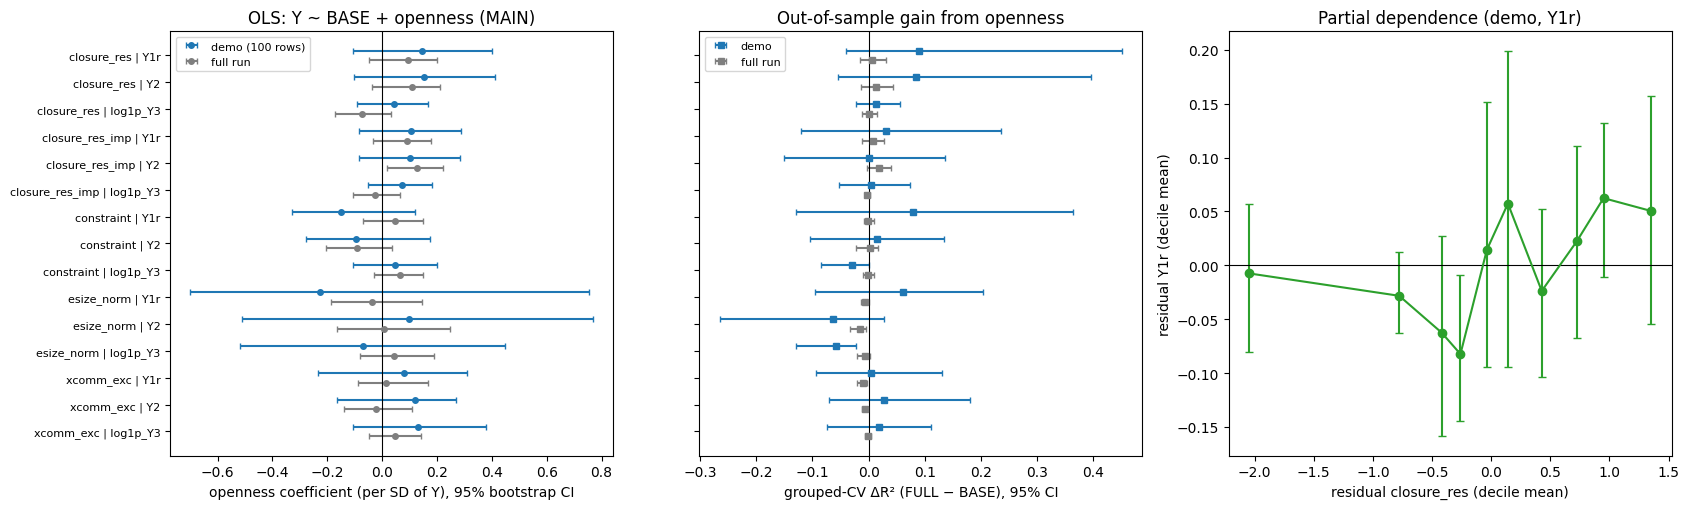

In [18]:
ref_coef = pd.DataFrame(data["reference_full_run"]["coef_table_primary"])
ref_cv = pd.DataFrame(data["reference_full_run"]["cv_delta_r2"])
key = ["openness", "outcome"]
cmp = coef[key + ["coef", "ci_lo", "ci_hi", "p_holm", "n_rows", "n_concepts"]].merge(
    ref_coef[key + ["coef", "ci_lo", "ci_hi", "p_holm", "n_rows", "n_concepts"]], on=key, suffixes=("_demo", "_full"))
cvc = cv[cv.model == "b_grouped_cv"][key + ["delta_r2", "ci_lo", "ci_hi"]].merge(
    ref_cv[ref_cv.model == "b_grouped_cv"][key + ["delta_r2", "ci_lo", "ci_hi"]], on=key, suffixes=("_demo", "_full"))
print(f"VERDICT (demo, {int(d.in_MAIN.sum())} MAIN rows): {verdict['verdict']}  |  "
      f"VERDICT (full run): {data['reference_full_run']['verdict']}")
print(verdict["interpretation"])
pd.set_option("display.width", 200)
display(cmp.round(4))
display(cvc.round(4))

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
ovs = ["closure_res_z", "closure_res_imp_z", "constraint_z", "esize_norm_z", "xcomm_exc_z"]
labels = [f"{ov.replace('_z', '')} | {y}" for ov in ovs for y in OUTCOMES]
ypos = np.arange(len(labels))
for off, suf, col, lab in [(-0.18, "_demo", "tab:blue", "demo (100 rows)"), (0.18, "_full", "tab:gray", "full run")]:
    r = cmp.set_index(key).reindex([(ov, y) for ov in ovs for y in OUTCOMES])
    sd = coef.set_index(key).reindex(r.index).sd_y.values if suf == "_demo" else \
        ref_coef.set_index(key).reindex(r.index).sd_y.values
    c, lo, hi = (r[f"coef{suf}"] / sd).values, (r[f"ci_lo{suf}"] / sd).values, (r[f"ci_hi{suf}"] / sd).values
    axes[0].errorbar(c, ypos + off, xerr=[c - lo, hi - c], fmt="o", color=col, capsize=2, ms=4, label=lab)
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_yticks(ypos, labels, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("openness coefficient (per SD of Y), 95% bootstrap CI")
axes[0].legend(fontsize=8)
axes[0].set_title("OLS: Y ~ BASE + openness (MAIN)")

r = cvc.set_index(key).reindex([(ov, y) for ov in ovs for y in OUTCOMES])
for off, suf, col, lab in [(-0.18, "_demo", "tab:blue", "demo"), (0.18, "_full", "tab:gray", "full run")]:
    c, lo, hi = r[f"delta_r2{suf}"].values, r[f"ci_lo{suf}"].values, r[f"ci_hi{suf}"].values
    axes[1].errorbar(c, ypos + off, xerr=[c - lo, hi - c], fmt="s", color=col, capsize=2, ms=4, label=lab)
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_yticks(ypos, [""] * len(ypos))
axes[1].invert_yaxis()
axes[1].set_xlabel("grouped-CV ΔR² (FULL − BASE), 95% CI")
axes[1].legend(fontsize=8)
axes[1].set_title("Out-of-sample gain from openness")

p = pdp[pdp.outcome == "Y1r"]
axes[2].errorbar(p.x_resid_mean, p.y_resid_mean, yerr=[p.y_resid_mean - p.ci_lo, p.ci_hi - p.y_resid_mean],
                 fmt="o-", color="tab:green", capsize=3)
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_xlabel("residual closure_res (decile mean)")
axes[2].set_ylabel("residual Y1r (decile mean)")
axes[2].set_title("Partial dependence (demo, Y1r)")
plt.tight_layout()
plt.show()